In [1]:
from graphfaker import GraphFaker
import networkx as nx
import matplotlib.pyplot as plt

c:\Users\Dee\root\Projects\dev\graphgeeks-lab\graphfaker\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
gf = GraphFaker()

In [3]:
G_flights = gf.generate_graph(source="flights", year=2024, month=1)

graphfaker:2025-07-29 17:32:46,648 - graphfaker - INFO - Fetching airlines lookup from BTS…
graphfaker:2025-07-29 17:32:48,233 - graphfaker - INFO - Fetching airports dataset from OpenFlights…
graphfaker:2025-07-29 17:32:48,940 - graphfaker - INFO - Fetching flight performance data for 2024-01 or date range None…
graphfaker:2025-07-29 17:33:33,360 - graphfaker - INFO - Fetched 1750 airlines, 1251 airports, 547271 flights.            
graphfaker:2025-07-29 17:33:33,364 - graphfaker - INFO - Adding 1750 airlines…
graphfaker:2025-07-29 17:33:34,274 - graphfaker - INFO - Adding 1251 airports + city nodes…
graphfaker:2025-07-29 17:33:35,185 - graphfaker - INFO - Adding 547271 flights + edges…
graphfaker:2025-07-29 17:40:17,125 - graphfaker - INFO - ✅ Graph built in 402.70s — 542805 nodes, 1617804 edges
graphfaker:2025-07-29 17:40:17,250 - graphfaker - INFO - Flight data for 2024-01


In [14]:
G_faker = gf.generate_graph(source = "faker", total_nodes = 100)

In [16]:
G_faker.number_of_edges()

1109

In [18]:
G_rand = gf.generate_graph(source="faker", total_nodes=50, total_edges=200)

In [19]:
G_rand.number_of_nodes()

100

In [9]:
G_rand.number_of_edges()

221

In [ ]:
# Sanitize attributes that are not GraphML-friendly
for _, data in G.nodes(data=True):
    if 'coordinates' in data and isinstance(data['coordinates'], tuple):
        lat, lon = data['coordinates']
        data['coordinates'] = f"{lat},{lon}"

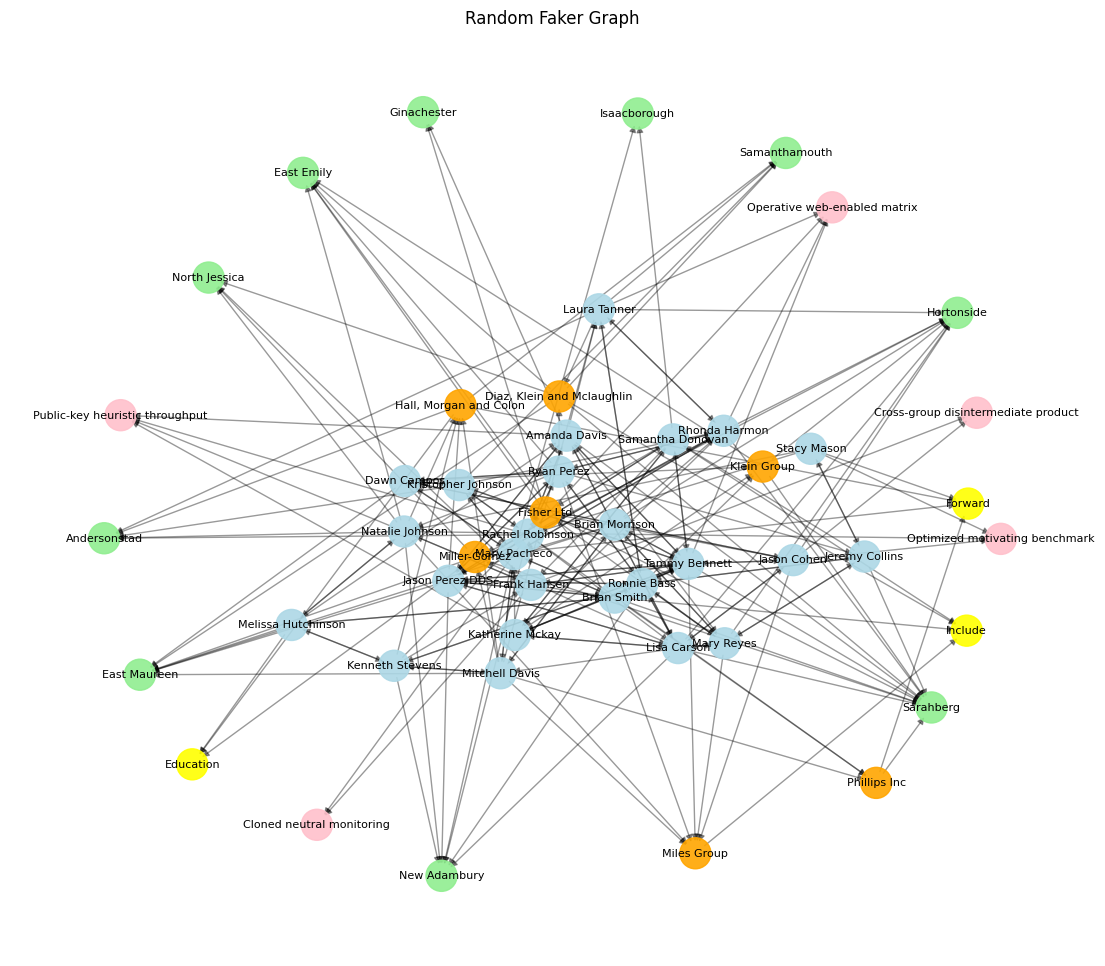

In [7]:
# If you’re in a notebook you usually don’t need to set a GUI backend:
# %matplotlib inline  

import networkx as nx
import matplotlib.pyplot as plt

def visualize_faker_graph(
    G,
    title,
    k: float = 1.5,
    iterations: int = 100
):
    """Visualize the graph using Matplotlib with a more spread-out layout."""
    plt.figure(figsize=(14, 12))
    # compute layout
    pos = nx.spring_layout(G, seed=42, k=k, iterations=iterations)

    # color map for node types
    color_map = {
        "Person": "lightblue",
        "Place": "lightgreen",
        "Organization": "orange",
        "Event": "pink",
        "Product": "yellow",
    }
    node_colors = [
        color_map.get(data.get("type"), "gray")
        for _, data in G.nodes(data=True)
    ]

    # draw nodes & edges
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, alpha=0.9)
    nx.draw_networkx_edges(G, pos, alpha=0.4)

    # build label dict and draw labels
    labels_dict = {n: data.get("name", "") for n, data in G.nodes(data=True)}
    nx.draw_networkx_labels(G, pos, labels=labels_dict, font_size=8)

    # set title correctly
    plt.title(title)
    plt.axis("off")
    plt.show()


# Example usage (make sure G_rand is defined; e.g. via GraphFaker.random_social_graph(...))
visualize_faker_graph(G_rand, title="Random Faker Graph")


In [12]:
gf.export_graph(G_rand, path="random_faker_graph.graphml")

✅ Graph exported to: c:\Users\Dee\root\Projects\dev\graphgeeks-lab\graphfaker\examples\random_faker_graph.graphml


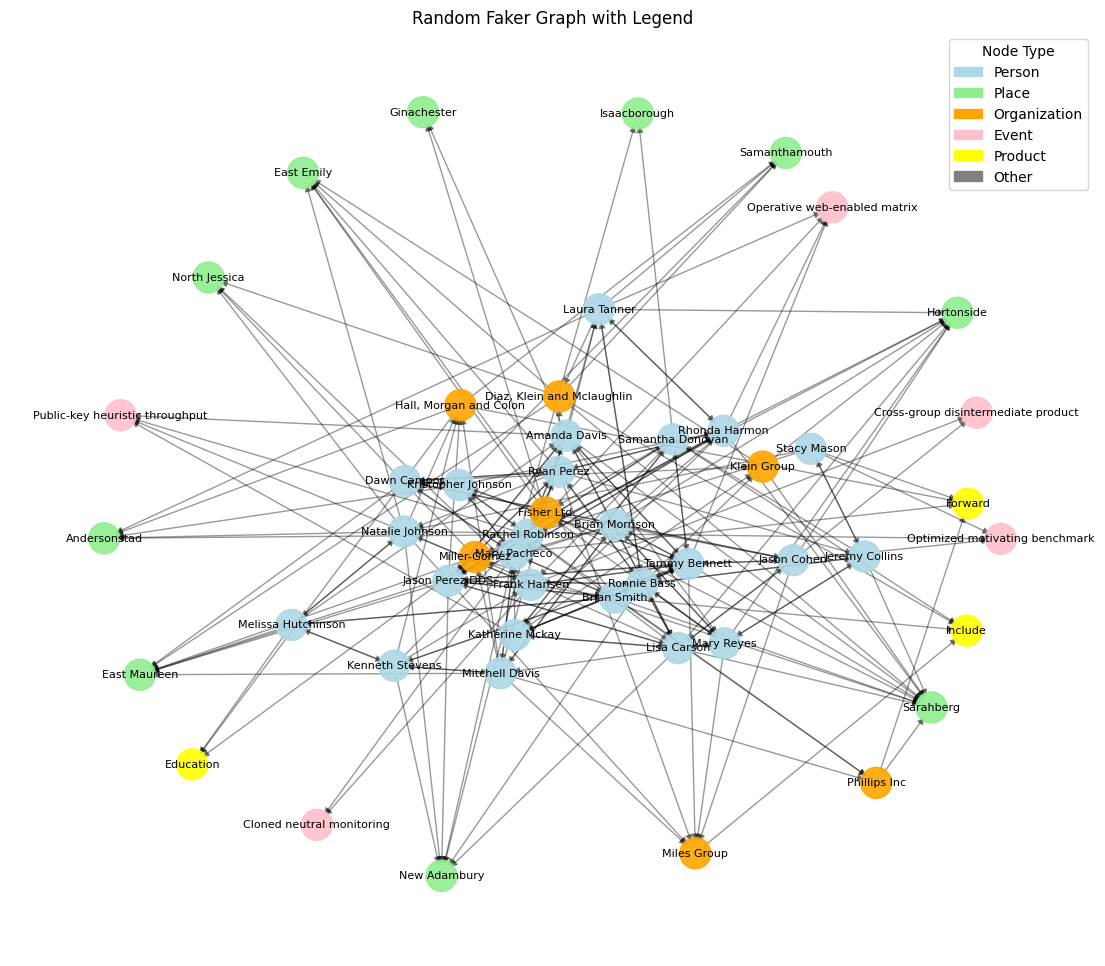

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def visualize_faker_graph_with_legend(
    G,
    title: str,
    k: float = 1.5,
    iterations: int = 100
):
    """Draw graph, color by node type, and add a legend."""
    plt.figure(figsize=(14, 12))
    pos = nx.spring_layout(G, seed=42, k=k, iterations=iterations)

    # define your type→color mapping
    color_map = {
        "Person": "lightblue",
        "Place": "lightgreen",
        "Organization": "orange",
        "Event": "pink",
        "Product": "yellow",
    }
    # fallback colour for any untyped nodes
    default_color = "gray"

    # build list of colours for nodes
    node_colors = [
        color_map.get(data.get("type"), default_color)
        for _, data in G.nodes(data=True)
    ]

    # draw
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, alpha=0.9)
    nx.draw_networkx_edges(G, pos, alpha=0.4)
    labels = {n: data.get("name", "") for n, data in G.nodes(data=True)}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

    # create legend patches
    legend_handles = [
        Patch(color=col, label=typ)
        for typ, col in color_map.items()
    ]
    legend_handles.append(Patch(color=default_color, label="Other"))
    plt.legend(handles=legend_handles, title="Node Type", loc="upper right")

    plt.title(title)
    plt.axis("off")
    plt.show()


# usage
visualize_faker_graph_with_legend(G_rand, title="Random Faker Graph with Legend")


In [ ]:
gf.export_graph(G_rand, path="random_faker_graph.graphml")

In [ ]:
## Intervactive visualization with PyVis
from pyvis.network import Network
import networkx as nx
from IPython.display import IFrame

# assume G_rand is already defined
net = Network(
    height="800px", width="100%", bgcolor="#ffffff", font_color="black"
)
net.barnes_hut()  # enable force-directed physics

# color mapping for node types
color_map = {
    "Person": "lightblue",
    "Place": "lightgreen",
    "Organization": "orange",
    "Event": "pink",
    "Product": "yellow",
}

# add nodes
for node, data in G_rand.nodes(data=True):
    net.add_node(
        node,
        label=data.get("name", str(node)),
        color=color_map.get(data.get("type"), "gray"),
        title=f"Type: {data.get('type', 'Unknown')}"
    )

# add edges
for u, v in G_rand.edges():
    net.add_edge(u, v)

# 4. Write out an HTML file (won’t open in browser automatically)
html_path = "faker_graph.html"
net.write_html(html_path)

# 5. Embed it right in the notebook
IFrame(src=html_path, width="100%", height="800px")

# write & display the interactive HTML
#net.show("faker_graph.html")

